# Notebook 3: Build Filtered National Road Networks

## Objectives

This notebook generalizes the Ontario National Road Network (NRN) filtering workflow to all provincial and territorial NRN road segment layers.

Two nested road network representations are constructed for each province and territory:

1. **Backbone network**
    - Freeway
    - Expressway / Highway
    - Ramp

2. **Freight-access network**
    - Freeway
    - Expressway / Highway
    - Ramp
    - Arterial

The purpose of these filters is to reduce graph size prior to graph construction while preserving the major transportation corridors required for national-scale energy and industrial systems modelling.

This notebook produces:

- filtered provincial road networks
- concatenated national road networks
- summary tables comparing retained road segments by province and territory

The resulting GeoDataFrames will serve as inputs to subsequent notebooks for:

- Canada-wide network assembly
- graph construction
- graph simplification
- region-to-region connectivity
- TEMOA encoding

In [25]:
from pathlib import Path
import sqlite3

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


# Define the location of the raw National Road Network (NRN) data

RAW_NRN = Path("../data_files/raw/nrn")

# Define the processed NRN output directory.

PROCESSED_NRN = Path("../data_files/processed/nrn")

PROCESSED_NRN.mkdir(
    parents=True,
    exist_ok=True,
)

# Province and territory abbreviations used throughout the preprocessing
# workflow

PROVINCES = [
    "AB", "BC", "MB", "NB", "NL", "NS",
    "NT", "NU", "ON", "PE", "QC", "SK", "YT",
]

In [2]:
# Define nested road network representations.
#
# Backbone network:
# Long-distance freight corridors consisting of freeways, highways,
# and ramps.
#
# Freight-access network:
# Backbone network plus arterial roads to improve connectivity to
# industrial sites, ports, terminals, and regional centroids.

BACKBONE_CLASSES = [
    "Freeway",
    "Expressway / Highway",
    "Ramp",
]

FREIGHT_ACCESS_CLASSES = BACKBONE_CLASSES + [
    "Arterial",
]

In [3]:
# Locate the English GeoPackage corresponding to a province or territory.

def get_nrn_gpkg_path(province: str) -> Path:
    """
    Return the English NRN GeoPackage corresponding to a province or territory.

    Args:
        province:
            Province or territory abbreviation.

    Returns:
        Path to the English GeoPackage.
    """

    province = province.upper()
    province_dir = RAW_NRN / province
    matches = list(province_dir.glob("*_en.gpkg"))

    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one English GPKG file for {province}, "
            f"found {len(matches)}."
        )

    return matches[0]


In [4]:
# Read the contents of a GeoPackage into a DataFrame.

def get_gpkg_contents(gpkg_path: Path) -> pd.DataFrame:
    """
    Return the GeoPackage contents table.

    Args:
        gpkg_path:
            Path to a GeoPackage file.

    Returns:
        GeoPackage contents table as a DataFrame.
    """

    with sqlite3.connect(gpkg_path) as conn:
        contents = pd.read_sql_query(
            """
            SELECT *
            FROM gpkg_contents
            """,
            conn,
        )

    return contents

In [5]:
# Determine the ROADSEG table name within a province's GeoPackage.
# Table names contain version numbers and therefore cannot be hardcoded.

def get_roadseg_table(gpkg_path: Path) -> str:
    """
    Return the ROADSEG table name contained in a provincial GeoPackage.

    Args:
        gpkg_path:
            Path to the provincial NRN GeoPackage.

    Returns:
        Name of the ROADSEG table.
    """

    contents = get_gpkg_contents(gpkg_path)

    matches = contents[
        contents["table_name"].str.endswith("_ROADSEG")
    ]["table_name"].tolist()

    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one ROADSEG table in {gpkg_path.name}, "
            f"found {len(matches)}: {matches}"
        )

    return matches[0]

In [6]:
# Load provincial and territorial road segments from the GeoPackages.

provincial_roads = {}

for province in PROVINCES:

    gpkg_path = get_nrn_gpkg_path(province)
    roadseg_table = get_roadseg_table(gpkg_path)

    roads = gpd.read_file(
        gpkg_path,
        layer=roadseg_table,
    )

    roads["province"] = province

    provincial_roads[province] = roads

    print(
        f"{province}: "
        f"{roads.shape[0]:,} road segments loaded."
    )

AB: 443,593 road segments loaded.
BC: 263,584 road segments loaded.
MB: 110,604 road segments loaded.
NB: 69,714 road segments loaded.
NL: 44,484 road segments loaded.
NS: 119,846 road segments loaded.
NT: 8,540 road segments loaded.
NU: 5,137 road segments loaded.
ON: 651,662 road segments loaded.
PE: 19,465 road segments loaded.
QC: 440,398 road segments loaded.
SK: 299,124 road segments loaded.
YT: 7,384 road segments loaded.


In [7]:
# Construct filtered road network representations for all provinces and territories

provincial_backbone = {}
provincial_freight_access = {}

for province, roads in provincial_roads.items():

    backbone = roads[
        roads["ROADCLASS"].isin(BACKBONE_CLASSES)
    ].copy()

    freight_access = roads[
        roads["ROADCLASS"].isin(FREIGHT_ACCESS_CLASSES)
    ].copy()

    provincial_backbone[province] = backbone
    provincial_freight_access[province] = freight_access

    print(
        f"{province}: "
        f"{backbone.shape[0]:,} backbone segments | "
        f"{freight_access.shape[0]:,} freight-access segments"
    )

AB: 20,643 backbone segments | 49,563 freight-access segments
BC: 15,270 backbone segments | 34,193 freight-access segments
MB: 22,365 backbone segments | 22,367 freight-access segments
NB: 5,129 backbone segments | 5,570 freight-access segments
NL: 8,436 backbone segments | 8,455 freight-access segments
NS: 4,362 backbone segments | 11,919 freight-access segments
NT: 984 backbone segments | 984 freight-access segments
NU: 0 backbone segments | 0 freight-access segments
ON: 26,964 backbone segments | 123,799 freight-access segments
PE: 340 backbone segments | 1,612 freight-access segments
QC: 39,430 backbone segments | 73,259 freight-access segments
SK: 21,315 backbone segments | 21,331 freight-access segments
YT: 2,022 backbone segments | 2,548 freight-access segments


In [12]:
# Construct national road network representations.

canada_backbone = gpd.GeoDataFrame(
    pd.concat(
        provincial_backbone.values(),
        ignore_index=True,
    )
)

canada_freight_access = gpd.GeoDataFrame(
    pd.concat(
        provincial_freight_access.values(),
        ignore_index=True,
    )
)

print(
    f"National backbone network: "
    f"{canada_backbone.shape[0]:,} segments"
)

print(
    f"National freight-access network: "
    f"{canada_freight_access.shape[0]:,} segments"
)

National backbone network: 167,260 segments
National freight-access network: 355,600 segments


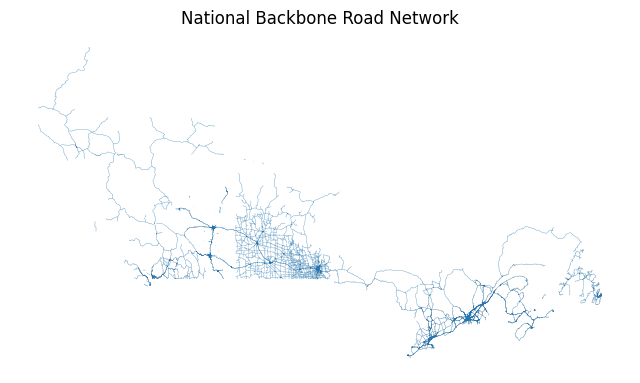

In [15]:
# Plot the national backbone network.

fig, ax = plt.subplots(
    figsize=(8, 8)
)

canada_backbone.plot(
    ax=ax,
    linewidth=0.2,
)

ax.set_title(
    "National Backbone Road Network"
)

ax.set_axis_off()

plt.show()

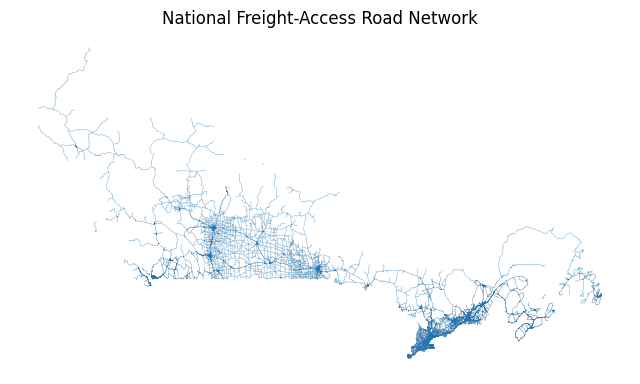

In [16]:
# Plot the national freight-access network.

fig, ax = plt.subplots(
    figsize=(8, 8)
)

canada_freight_access.plot(
    ax=ax,
    linewidth=0.2,
)

ax.set_title(
    "National Freight-Access Road Network"
)

ax.set_axis_off()

plt.show()

In [21]:
# Summarize the number of road segments retained in each network representation.

summary_rows = []

for province in PROVINCES:

    full_segments = len(
        provincial_roads[province]
    )

    backbone_segments = len(
        provincial_backbone[province]
    )

    freight_access_segments = len(
        provincial_freight_access[province]
    )

    summary_rows.append(
        {
            "province": province,
            "full_segments": full_segments,
            "backbone_segments": backbone_segments,
            "freight_access_segments": freight_access_segments,
            "backbone_percent": round(
                100 * backbone_segments / full_segments,
                1,
            ),
            "freight_access_percent": round(
                100 * freight_access_segments / full_segments,
                1,
            ),
        }
    )


# Append a national summary row.

full_segments = sum(
    row["full_segments"]
    for row in summary_rows
)

backbone_segments = sum(
    row["backbone_segments"]
    for row in summary_rows
)

freight_access_segments = sum(
    row["freight_access_segments"]
    for row in summary_rows
)

summary_rows.append(
    {
        "province": "Canada",
        "full_segments": full_segments,
        "backbone_segments": backbone_segments,
        "freight_access_segments": freight_access_segments,
        "backbone_percent": round(
            100 * backbone_segments / full_segments,
            1,
        ),
        "freight_access_percent": round(
            100 * freight_access_segments / full_segments,
            1,
        ),
    }
)


# Construct the summary table.

network_summary = pd.DataFrame(
    summary_rows
)


# Display percentages with percent signs.

network_summary.style.format(
    {
        "backbone_percent": "{:.1f}%",
        "freight_access_percent": "{:.1f}%",
    }
)

,province,full_segments,backbone_segments,freight_access_segments,backbone_percent,freight_access_percent
0,AB,443593,20643,49563,4.7%,11.2%
1,BC,263584,15270,34193,5.8%,13.0%
2,MB,110604,22365,22367,20.2%,20.2%
3,NB,69714,5129,5570,7.4%,8.0%
4,NL,44484,8436,8455,19.0%,19.0%
5,NS,119846,4362,11919,3.6%,9.9%
6,NT,8540,984,984,11.5%,11.5%
7,NU,5137,0,0,0.0%,0.0%
8,ON,651662,26964,123799,4.1%,19.0%
9,PE,19465,340,1612,1.7%,8.3%


In [22]:
# Plot provincial and territorial road networks as subplot panels.

def plot_provincial_networks(
    provincial_networks: dict,
    title: str,
    linewidth: float = 0.2,
) -> None:
    """
    Plot provincial and territorial road networks as a subplot grid.

    Args:
        provincial_networks:
            Dictionary mapping province or territory abbreviations to
            GeoDataFrames.
        title:
            Figure title.
        linewidth:
            Width of plotted road segment lines.
    """

    n_cols = 4
    n_rows = 4

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(14, 14),
    )

    axes = axes.flatten()

    for index, province in enumerate(PROVINCES):
        ax = axes[index]
        roads = provincial_networks[province]

        if len(roads) > 0:
            roads.plot(
                ax=ax,
                linewidth=linewidth,
            )

        ax.set_title(province)
        ax.set_axis_off()

    for ax in axes[len(PROVINCES):]:
        ax.set_visible(False)

    fig.suptitle(
        title,
        fontsize=16,
    )

    plt.tight_layout()
    plt.show()

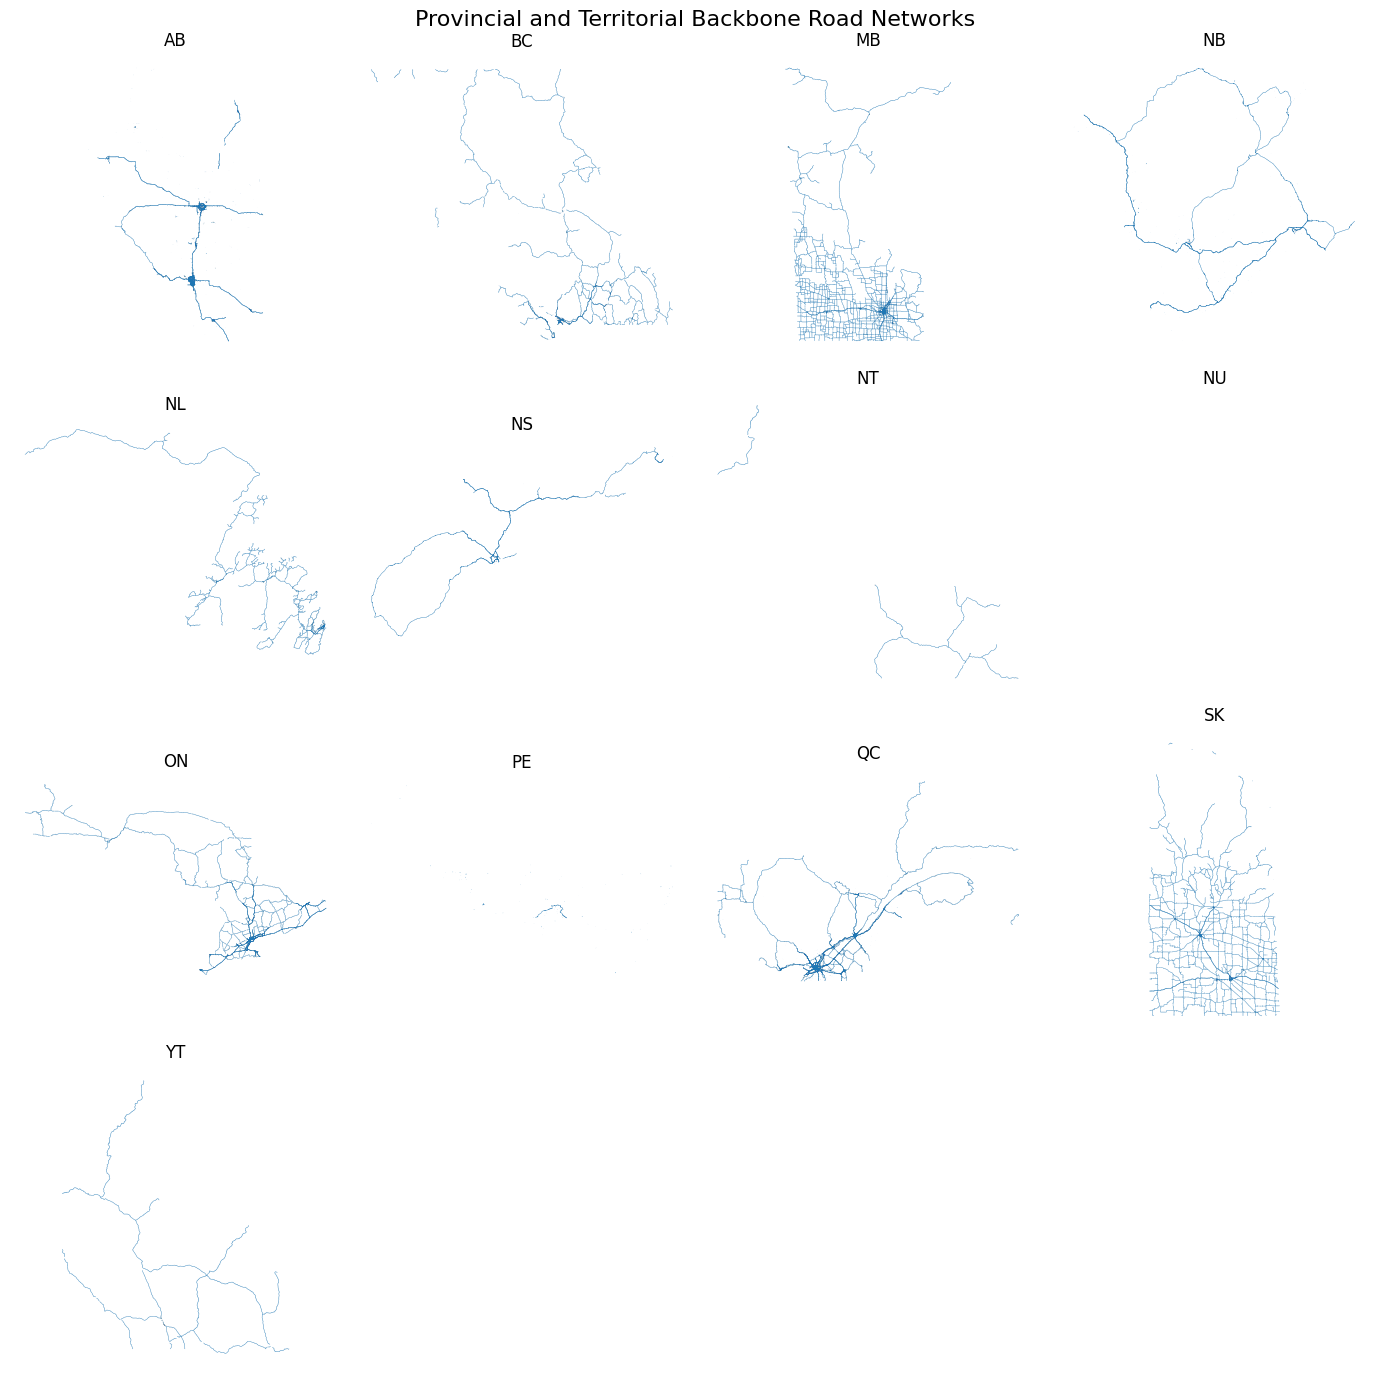

In [23]:
# Plot the provincial and territorial backbone road networks.
plot_provincial_networks(
    provincial_backbone,
    title="Provincial and Territorial Backbone Road Networks",
    linewidth=0.3,
)

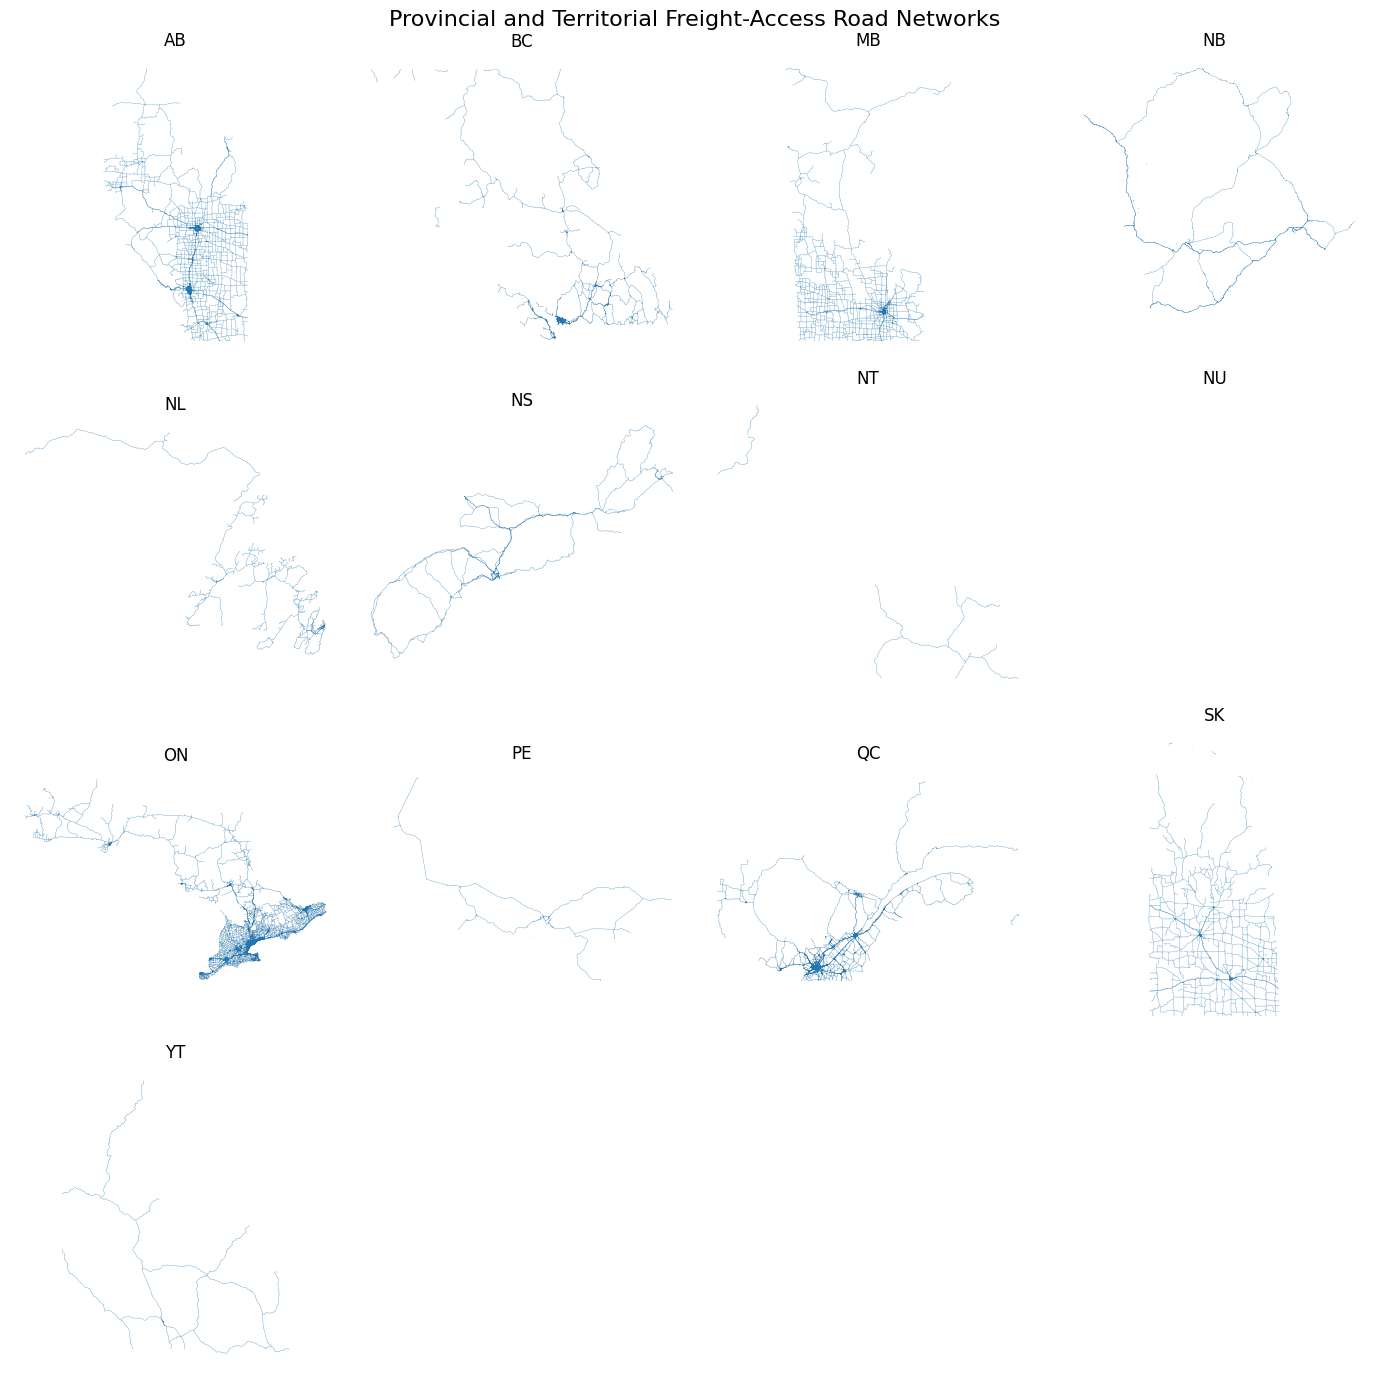

In [24]:
# Plot the provincial and territorial freight-access road networks.
plot_provincial_networks(
    provincial_freight_access,
    title="Provincial and Territorial Freight-Access Road Networks",
    linewidth=0.2,
)

In [26]:
# Export provincial and territorial filtered road networks.

for province in PROVINCES:

    output_path = PROCESSED_NRN / f"{province}_filtered_road_networks.gpkg"

    provincial_backbone[province].to_file(
        output_path,
        layer="backbone",
        driver="GPKG",
    )

    provincial_freight_access[province].to_file(
        output_path,
        layer="freight_access",
        driver="GPKG",
    )

    print(f"{province}: exported {output_path.name}")

AB: exported AB_filtered_road_networks.gpkg
BC: exported BC_filtered_road_networks.gpkg
MB: exported MB_filtered_road_networks.gpkg
NB: exported NB_filtered_road_networks.gpkg
NL: exported NL_filtered_road_networks.gpkg
NS: exported NS_filtered_road_networks.gpkg
NT: exported NT_filtered_road_networks.gpkg
NU: exported NU_filtered_road_networks.gpkg
ON: exported ON_filtered_road_networks.gpkg
PE: exported PE_filtered_road_networks.gpkg
QC: exported QC_filtered_road_networks.gpkg
SK: exported SK_filtered_road_networks.gpkg
YT: exported YT_filtered_road_networks.gpkg


In [27]:
# Export national filtered road networks.

canada_output_path = PROCESSED_NRN / "CANADA_filtered_road_networks.gpkg"

canada_backbone.to_file(
    canada_output_path,
    layer="backbone",
    driver="GPKG",
)

canada_freight_access.to_file(
    canada_output_path,
    layer="freight_access",
    driver="GPKG",
)

print(f"Canada: exported {canada_output_path.name}")

Canada: exported CANADA_filtered_road_networks.gpkg


In [28]:
# Export network summary table.

network_summary.to_csv(
    PROCESSED_NRN / "filtered_road_network_summary.csv",
    index=False,
)

# Conclusions

This notebook generalized the Ontario road network filtering workflow to all provinces and territories using the National Road Network (NRN) database.

Two nested network representations were constructed:

### Backbone network

- Freeway
- Expressway / Highway
- Ramp

### Freight-access network

- Backbone network
- Arterial roads

Visual inspection demonstrated that the filtering procedure preserves the major Canadian transportation corridors while substantially reducing graph size.

Of approximately 2.48 million NRN road segments:

- 167,260 segments (6.7%) were retained in the backbone network.
- 355,600 segments (14.3%) were retained in the freight-access network.

Provincial and national GeoPackage files were exported for both network representations.

These processed datasets will serve as inputs to subsequent workflows involving:

- graph construction
- graph simplification
- spatial aggregation
- region encoding
- NetworkX analysis
- TEMOA database generation

The results demonstrate that the Canadian road network can be reduced by approximately an order of magnitude while preserving the primary freight corridors required for national-scale energy and industrial systems modelling.